# Common Functions

In [5]:
# =========================================================
# 0. Common Functions
# =========================================================

# If needed in Colab:
# !pip install mlxtend -q
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    adjusted_rand_score,
    confusion_matrix,
    classification_report
)
from scipy.optimize import linear_sum_assignment

from mlxtend.frequent_patterns import apriori, association_rules


# =========================================================
# Load Data
# =========================================================
df = pd.read_csv("mobile_price.csv")

target_col = "price_range"
X_df = df.drop(columns=[target_col])
y = df[target_col].values

seeds = [0, 10, 42, 100, 999]

SAVE_FIG_DIR = "kmeans_rule_figures"
os.makedirs(SAVE_FIG_DIR, exist_ok=True)

print("Data shape:", df.shape)
print("Feature shape:", X_df.shape)
print("Class distribution:")
print(df[target_col].value_counts().sort_index())


# =========================================================
# Cluster Label Mapping
# =========================================================
def map_clusters_to_labels(y_true, y_cluster):
    labels = np.unique(y_true)
    clusters = np.unique(y_cluster)

    cost_matrix = np.zeros((len(labels), len(clusters)), dtype=int)

    for i, label in enumerate(labels):
        for j, cluster in enumerate(clusters):
            cost_matrix[i, j] = np.sum(
                (y_true == label) & (y_cluster == cluster)
            )

    row_ind, col_ind = linear_sum_assignment(-cost_matrix)

    cluster_to_label = {}
    for r, c in zip(row_ind, col_ind):
        cluster_to_label[clusters[c]] = labels[r]

    y_pred = np.array([cluster_to_label[c] for c in y_cluster])
    return y_pred


def evaluate_clustering(y_true, y_cluster):
    y_pred = map_clusters_to_labels(y_true, y_cluster)

    acc = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true,y_pred,average="macro",zero_division=0)

    recall = recall_score(y_true,y_pred,average="macro",zero_division=0)

    f1 = f1_score(y_true,y_pred,average="macro",zero_division=0)

    ari = adjusted_rand_score(y_true, y_cluster)

    return acc, precision, recall, f1, ari, y_pred


# =========================================================
# K-means Runner
# =========================================================
def run_kmeans_on_features(X, y, seeds, method_name="K-means", n_init=30):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    results = []
    cluster_dict = {}
    pred_dict = {}

    for seed in seeds:
        kmeans = KMeans(
            n_clusters=4,
            random_state=seed,
            n_init=n_init
        )

        clusters = kmeans.fit_predict(X_scaled)

        acc, precision, recall, f1, ari, y_pred = evaluate_clustering(
            y,
            clusters
        )

        results.append({"Method": method_name,"seed": seed,"Accuracy": acc,"Precision": precision,"Recall": recall,"F1-score": f1,"ARI": ari})

        cluster_dict[seed] = clusters
        pred_dict[seed] = y_pred

    results_df = pd.DataFrame(results)

    return results_df, X_scaled, cluster_dict, pred_dict


# =========================================================
# Association Rule Mining
# =========================================================
def discretize_features(df, target_col="price_range", n_bins=3):
    df_disc = pd.DataFrame()

    for col in df.columns:
        if col == target_col:
            continue

        if df[col].nunique() <= 2:
            df_disc[col] = col + "=" + df[col].astype(str)

        else:
            labels = ["low", "mid", "high"]

            df_disc[col] = pd.qcut(
                df[col],
                q=n_bins,
                labels=labels,
                duplicates="drop"
            )

            df_disc[col] = col + "=" + df_disc[col].astype(str)

    df_disc[target_col] = target_col + "=" + df[target_col].astype(str)

    return df_disc


def build_transaction_onehot(df_disc):
    all_items = []

    for col in df_disc.columns:
        all_items.extend(df_disc[col].unique().tolist())

    all_items = sorted(list(set(all_items)))

    onehot = pd.DataFrame(
        False,
        index=np.arange(len(df_disc)),
        columns=all_items
    )

    for col in df_disc.columns:
        values = df_disc[col].values

        for i, item in enumerate(values):
            onehot.at[i, item] = True

    return onehot


def mine_price_rules(df,target_col="price_range",min_support=0.02,min_confidence=0.30,max_rules_per_class=20):
    df_disc = discretize_features(
        df,
        target_col=target_col,
        n_bins=3
    )

    onehot = build_transaction_onehot(df_disc)

    frequent_itemsets = apriori(
        onehot,
        min_support=min_support,
        use_colnames=True,
        max_len=3
    )

    if len(frequent_itemsets) == 0:
        print("No frequent itemsets found.")
        return pd.DataFrame(), df_disc

    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=min_confidence
    )

    if len(rules) == 0:
        print("No association rules found.")
        return pd.DataFrame(), df_disc

    price_rules = rules[
        rules["consequents"].apply(
            lambda x: len(x) == 1 and list(x)[0].startswith(target_col + "=")
        )
    ].copy()

    if len(price_rules) == 0:
        print("No price_range-related rules found.")
        return pd.DataFrame(), df_disc

    price_rules = price_rules.sort_values(
        by=["confidence", "lift", "support"],
        ascending=False
    )

    selected_rules = []

    for cls in sorted(df[target_col].unique()):
        cls_item = f"{target_col}={cls}"

        cls_rules = price_rules[
            price_rules["consequents"].apply(
                lambda x: cls_item in list(x)
            )
        ].head(max_rules_per_class)

        selected_rules.append(cls_rules)

    selected_rules = pd.concat(selected_rules, axis=0).reset_index(drop=True)

    return selected_rules, df_disc


def build_rule_features(df, rules, target_col="price_range"):
    df_disc = discretize_features(
        df,
        target_col=target_col,
        n_bins=3
    )

    if len(rules) == 0:
        return pd.DataFrame(index=np.arange(len(df)))

    rule_features = np.zeros((len(df), len(rules)))

    for rule_idx, rule in rules.iterrows():
        antecedents = list(rule["antecedents"])

        confidence = rule["confidence"]
        lift = rule["lift"]

        rule_weight = confidence * lift

        for i in range(len(df_disc)):
            matched = True

            for item in antecedents:
                col = item.split("=")[0]

                if df_disc.loc[i, col] != item:
                    matched = False
                    break

            if matched:
                rule_features[i, rule_idx] = rule_weight

    rule_feature_df = pd.DataFrame(
        rule_features,
        columns=[f"rule_{i}" for i in range(len(rules))]
    )

    return rule_feature_df


# =========================================================
# Plotting Helpers
# =========================================================
def summarize_results(results_df):
    summary = results_df.groupby("Method")[
        ["Accuracy", "Precision", "Recall", "F1-score", "ARI"]
    ].mean().reset_index()

    return summary


def plot_metric_bar(summary_df, title, save_path=None):
    metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ARI"]

    method_name = summary_df["Method"].iloc[0]
    values = summary_df[metrics].iloc[0].values

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(metrics, values)

    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.01,
            f"{val:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def plot_cluster_scatter(X_feature, clusters, title, save_path=None):
    pca_vis = PCA(n_components=2, random_state=42)
    X_vis = pca_vis.fit_transform(X_feature)

    fig, ax = plt.subplots(figsize=(8, 6))

    for c in sorted(np.unique(clusters)):
        idx = clusters == c

        ax.scatter(X_vis[idx, 0],X_vis[idx, 1],s=20,alpha=0.7,label=f"cluster {c}")

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def plot_true_class_split(X_feature, y, title_prefix, save_path=None):
    pca_vis = PCA(n_components=2, random_state=42)
    X_vis = pca_vis.fit_transform(X_feature)

    classes = sorted(np.unique(y))

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()

    for idx, cls in enumerate(classes):
        ax = axes[idx]

        class_mask = y == cls
        other_mask = y != cls

        ax.scatter(X_vis[other_mask, 0], X_vis[other_mask, 1],s=10,alpha=0.12, label="Other classes")

        ax.scatter(X_vis[class_mask, 0], X_vis[class_mask, 1],s=18, alpha=0.8,label=f"price_range={cls}")

        ax.set_title(f"{title_prefix}: price_range={cls}")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def plot_confusion_matrix(y_true, y_pred, title, save_path=None):
    labels = sorted(np.unique(y_true))

    cm = confusion_matrix(y_true,y_pred,labels=labels)

    fig, ax = plt.subplots(figsize=(7, 6))

    im = ax.imshow(cm)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)

    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(title)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Count")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i,  str(cm[i, j]),ha="center",va="center",fontsize=10)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def plot_per_class_metrics(y_true, y_pred, title, save_path=None):
    report = classification_report(y_true,y_pred,output_dict=True,zero_division=0)
    classes = [str(c) for c in sorted(np.unique(y_true))]

    precision = [report[c]["precision"] for c in classes]
    recall = [report[c]["recall"] for c in classes]
    f1 = [report[c]["f1-score"] for c in classes]

    x = np.arange(len(classes))
    width = 0.25

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.bar(x - width, precision, width, label="Precision")
    ax.bar(x, recall, width, label="Recall")
    ax.bar(x + width, f1, width, label="F1-score")

    ax.set_xticks(x)
    ax.set_xticklabels([f"price_range={c}" for c in classes])

    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def plot_final_comparison(final_summary, save_path=None):
    metrics = ["Accuracy", "F1-score", "ARI"]
    methods = final_summary["Method"].tolist()

    x = np.arange(len(methods))
    width = 0.22

    fig, ax = plt.subplots(figsize=(12, 6))

    for i, metric in enumerate(metrics):
        ax.bar(
            x + i * width - width,
            final_summary[metric],
            width,
            label=metric
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        methods,
        rotation=0,
        ha="center"
    )

    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title("Final Comparison of Average Performance")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    for i, metric in enumerate(metrics):
        for j, val in enumerate(final_summary[metric]):
            ax.text(
                x[j] + i * width - width,
                val + 0.008,
                f"{val:.4f}",
                ha="center",
                va="bottom",
                fontsize=9,
                rotation=0
            )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.show()

Data shape: (2000, 21)
Feature shape: (2000, 20)
Class distribution:
price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64


# Notice
可能會出現
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

這個訊息是 DeprecationWarning，不是程式錯誤。主要原因是目前使用的 Python 3.12 中，datetime.utcnow() 已被標記為未來會移除的舊寫法；但 jupyter_client 套件內部仍使用這個函式，因此產生警告。

可能要重新多按幾次執行就可解決 (在Colab跑發現多按幾次會不見)

# Original K-means


========== Original K-means Results ==========


,Method,seed,Accuracy,Precision,Recall,F1-score,ARI
0,Original K-means,0,0.2945,0.2940,0.2945,0.2926,0.0053
1,Original K-means,10,0.2955,0.2950,0.2955,0.2937,0.0057
2,Original K-means,42,0.2945,0.2941,0.2945,0.2927,0.0053
3,Original K-means,100,0.2955,0.2950,0.2955,0.2935,0.0055
4,Original K-means,999,0.2960,0.2956,0.2960,0.2940,0.0057



========== Original K-means Average ==========


,Method,Accuracy,Precision,Recall,F1-score,ARI
0,Original K-means,0.2952,0.2948,0.2952,0.2933,0.0055


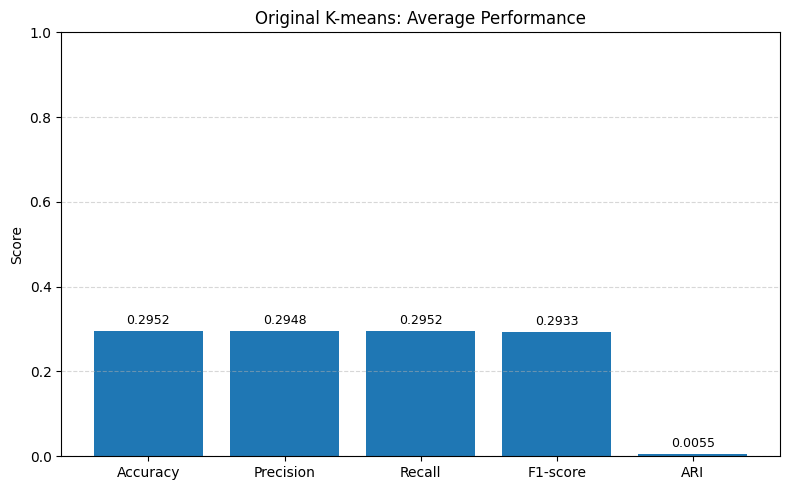

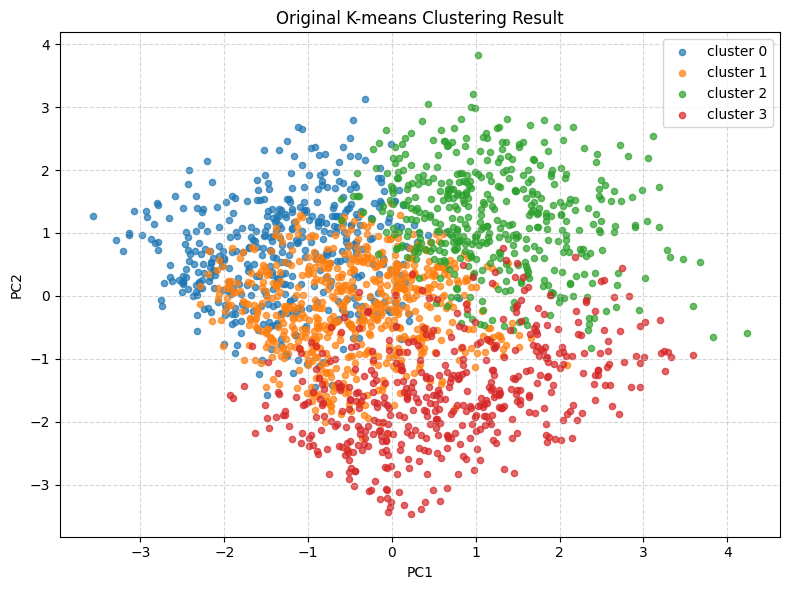

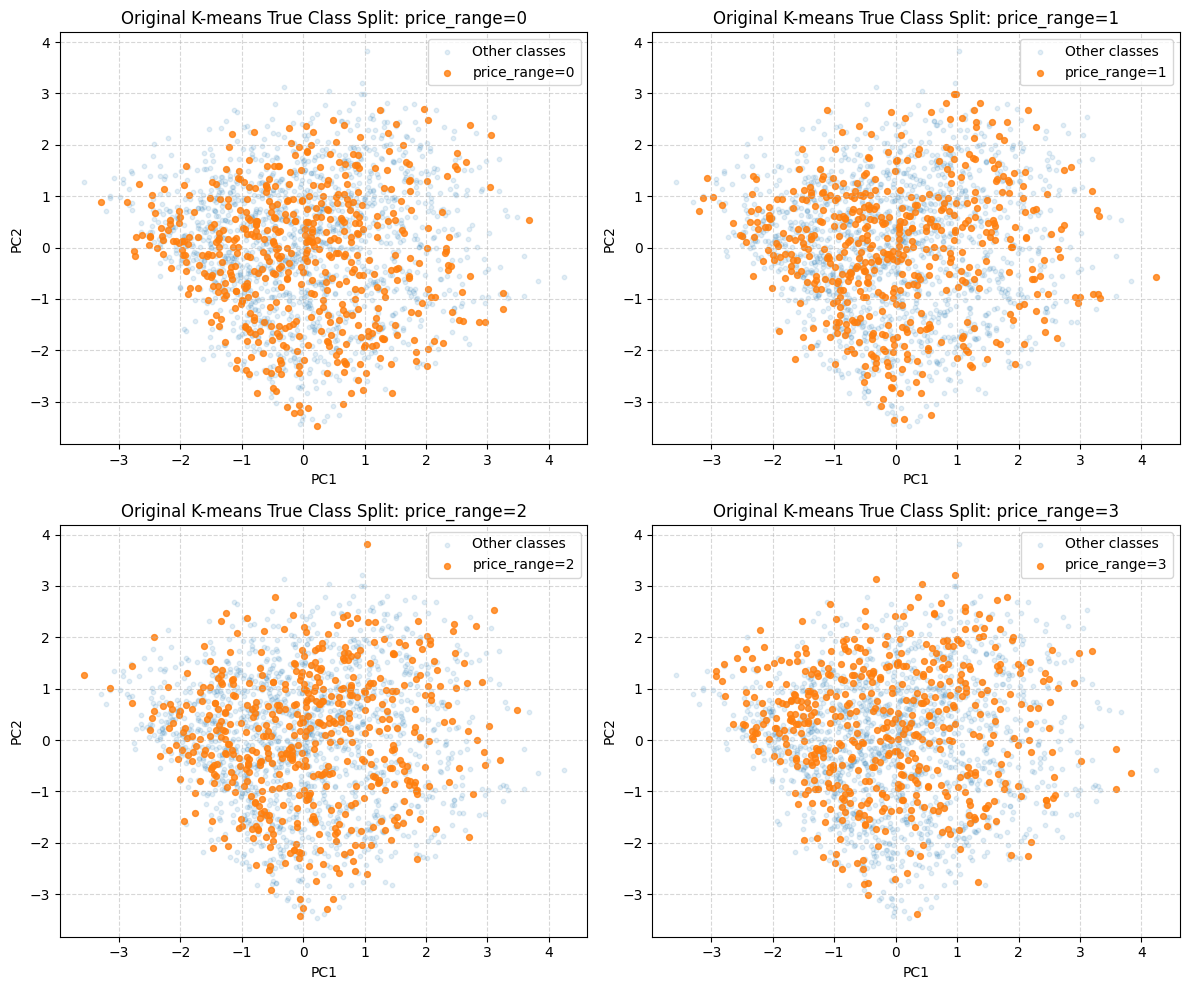

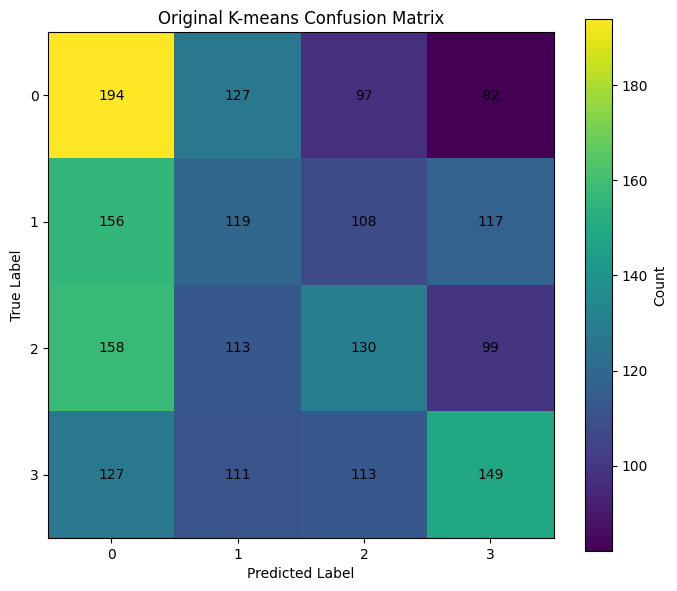

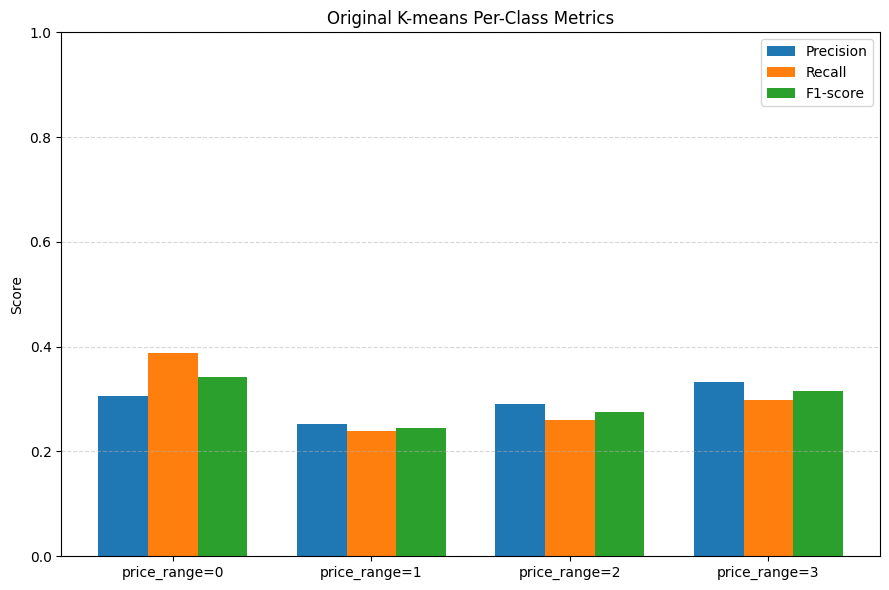

In [6]:
# =========================================================
# 1. Original K-means
# =========================================================
warnings.filterwarnings("ignore")
original_results, X_original_scaled, original_clusters, original_preds = run_kmeans_on_features(
    X_df,
    y,
    seeds,
    method_name="Original K-means",
    n_init=30
)

original_summary = summarize_results(original_results)

print("\n========== Original K-means Results ==========")
display(original_results.round(4))

print("\n========== Original K-means Average ==========")
display(original_summary.round(4))


# Use seed=999 for visualization
vis_seed = 999
original_cluster_999 = original_clusters[vis_seed]
original_pred_999 = original_preds[vis_seed]

plot_metric_bar(
    original_summary,
    title="Original K-means: Average Performance",
    save_path=os.path.join(SAVE_FIG_DIR, "01_original_metrics.png")
)

plot_cluster_scatter(
    X_original_scaled,
    original_cluster_999,
    title="Original K-means Clustering Result",
    save_path=os.path.join(SAVE_FIG_DIR, "01_original_cluster_scatter.png")
)

plot_true_class_split(X_original_scaled,y,title_prefix="Original K-means True Class Split",save_path=os.path.join(SAVE_FIG_DIR, "01_original_true_class_split.png"))

plot_confusion_matrix(y,original_pred_999,title="Original K-means Confusion Matrix",save_path=os.path.join(SAVE_FIG_DIR, "01_original_confusion_matrix.png"))

plot_per_class_metrics(y,original_pred_999,title="Original K-means Per-Class Metrics",save_path=os.path.join(SAVE_FIG_DIR, "01_original_per_class_metrics.png"))

# Rule-Augmented K-means


Number of selected association rules: 80

Top Association Rules:


,antecedents,consequents,support,confidence,lift
0,"(battery_power=low, ram=low)",(price_range=0),0.0995,0.938679,3.754717
1,"(px_width=low, ram=low)",(price_range=0),0.0975,0.882353,3.529412
2,"(px_height=low, ram=low)",(price_range=0),0.0935,0.882075,3.528302
3,"(n_cores=high, ram=low)",(price_range=0),0.0650,0.783133,3.132530
4,"(m_dep=low, ram=low)",(price_range=0),0.0940,0.767347,3.069388
5,"(px_height=mid, ram=low)",(price_range=0),0.0885,0.762931,3.051724
6,"(sc_w=mid, ram=low)",(price_range=0),0.0770,0.758621,3.034483
7,"(fc=mid, ram=low)",(price_range=0),0.0765,0.757426,3.029703
8,"(talk_time=mid, ram=low)",(price_range=0),0.0745,0.756345,3.025381
9,"(px_width=mid, ram=low)",(price_range=0),0.0855,0.753304,3.013216



========== Rule-Augmented K-means Results ==========


,Method,seed,Accuracy,Precision,Recall,F1-score,ARI
0,Rule-Augmented K-means,0,0.6595,0.6311,0.6595,0.6270,0.4447
1,Rule-Augmented K-means,10,0.6585,0.6296,0.6585,0.6258,0.4444
2,Rule-Augmented K-means,42,0.6590,0.6304,0.6590,0.6264,0.4446
3,Rule-Augmented K-means,100,0.6585,0.6297,0.6585,0.6262,0.4440
4,Rule-Augmented K-means,999,0.6610,0.6334,0.6610,0.6289,0.4451



========== Rule-Augmented K-means Average ==========


,Method,Accuracy,Precision,Recall,F1-score,ARI
0,Rule-Augmented K-means,0.6593,0.6308,0.6593,0.6269,0.4445


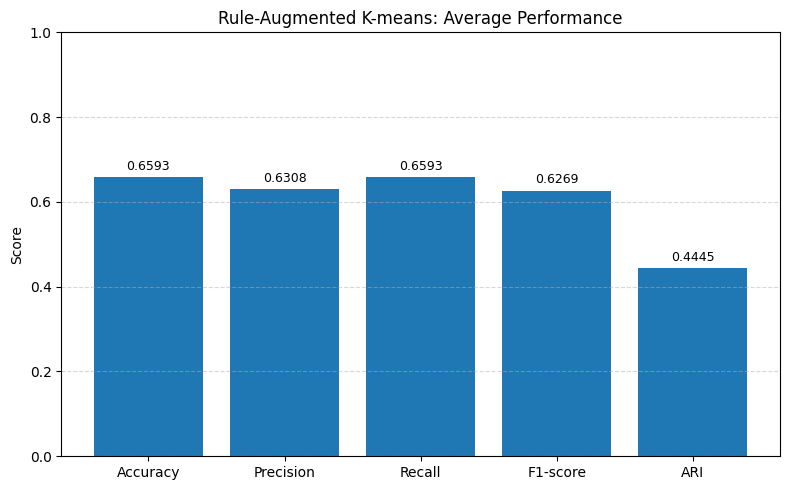

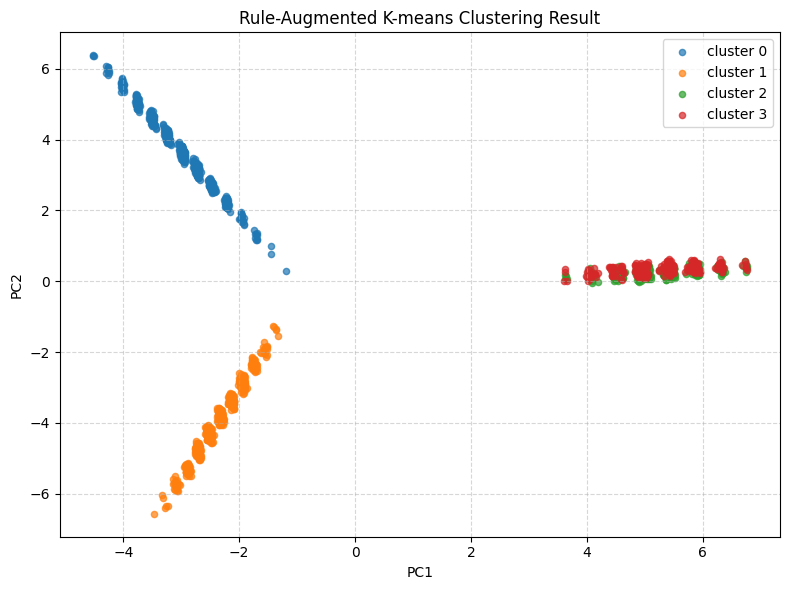

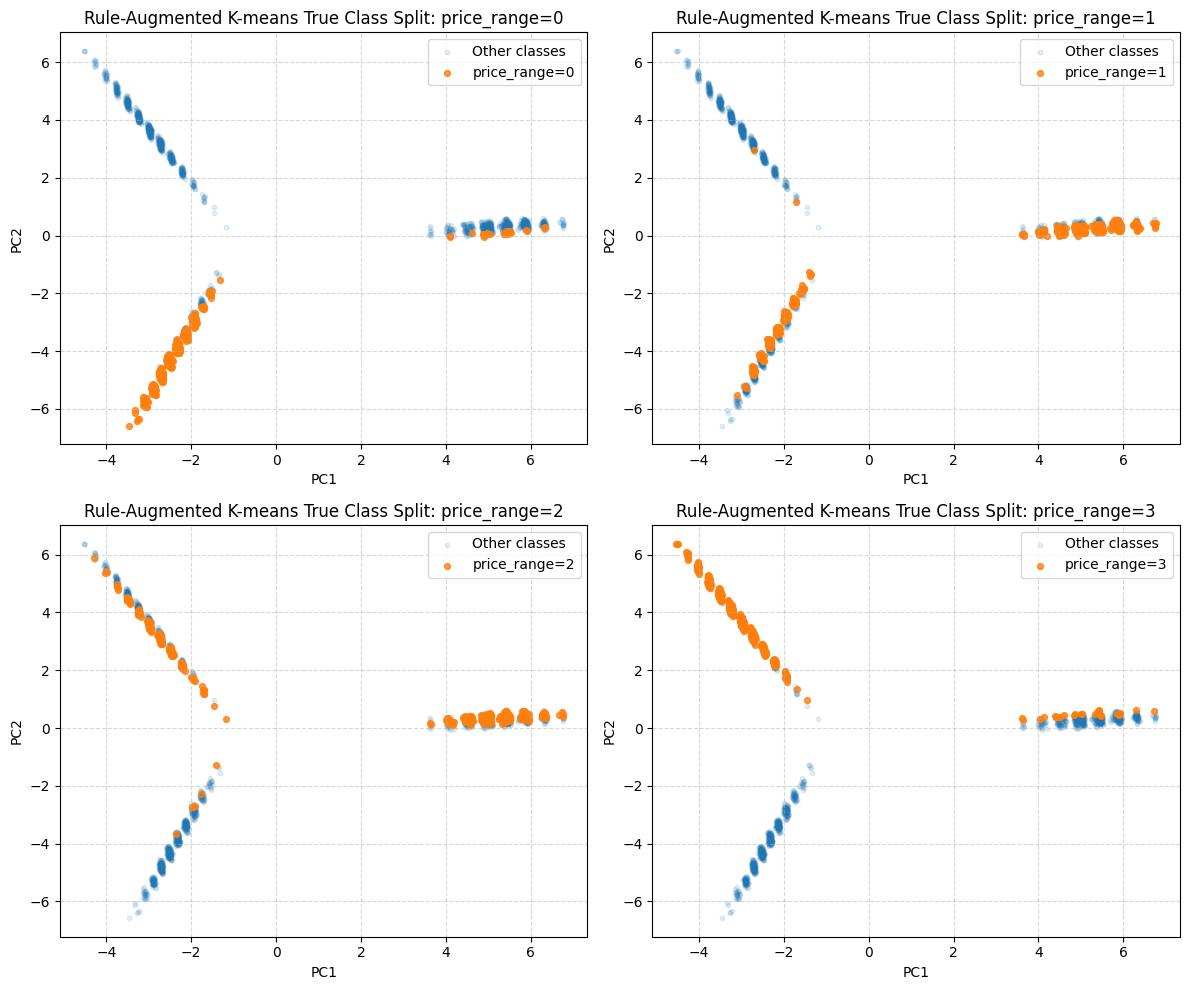

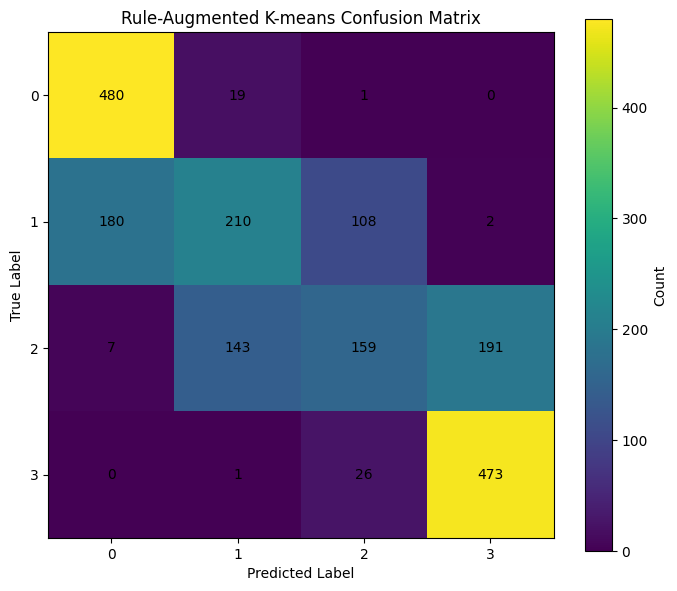

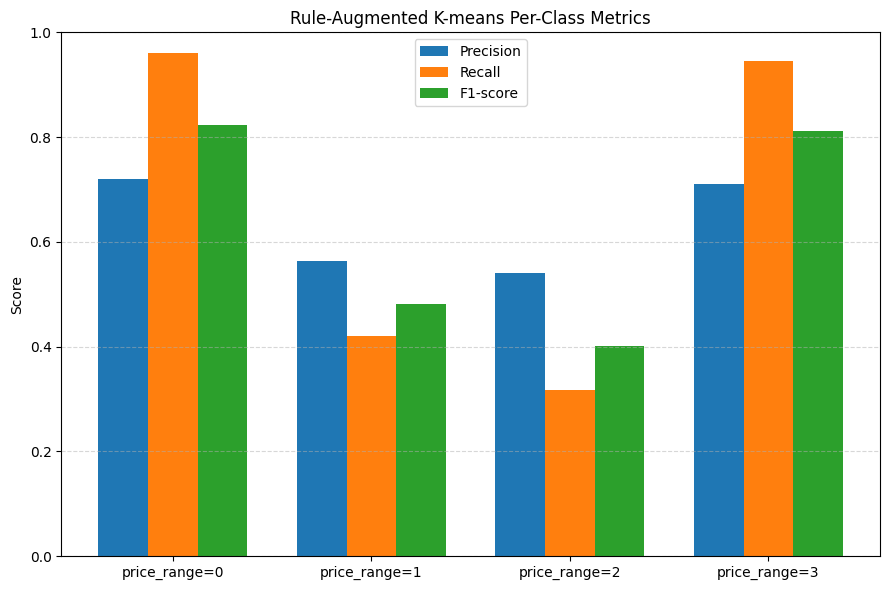

In [7]:
# =========================================================
# 2. Rule-Augmented K-means
# =========================================================

rules, _ = mine_price_rules(df,target_col="price_range",min_support=0.02,min_confidence=0.30,max_rules_per_class=20)

print("\nNumber of selected association rules:", len(rules))

if len(rules) > 0:
    print("\nTop Association Rules:")
    display(
        rules[
            ["antecedents", "consequents", "support", "confidence", "lift"]
        ].head(10)
    )

rule_feature_df = build_rule_features(df,rules,target_col="price_range")

X_rule_aug = pd.concat(
    [
        X_df.reset_index(drop=True),
        rule_feature_df.reset_index(drop=True)
    ],
    axis=1
)

rule_augmented_results, X_rule_aug_scaled, rule_aug_clusters, rule_aug_preds = run_kmeans_on_features(
    X_rule_aug,
    y,
    seeds,
    method_name="Rule-Augmented K-means",
    n_init=30
)

rule_augmented_summary = summarize_results(rule_augmented_results)

print("\n========== Rule-Augmented K-means Results ==========")
display(rule_augmented_results.round(4))

print("\n========== Rule-Augmented K-means Average ==========")
display(rule_augmented_summary.round(4))


# Use seed=999 for visualization
vis_seed = 999
rule_aug_cluster_999 = rule_aug_clusters[vis_seed]
rule_aug_pred_999 = rule_aug_preds[vis_seed]

plot_metric_bar(
    rule_augmented_summary,
    title="Rule-Augmented K-means: Average Performance",
    save_path=os.path.join(SAVE_FIG_DIR, "02_rule_augmented_metrics.png")
)

plot_cluster_scatter(
    X_rule_aug_scaled,
    rule_aug_cluster_999,
    title="Rule-Augmented K-means Clustering Result",
    save_path=os.path.join(SAVE_FIG_DIR, "02_rule_augmented_cluster_scatter.png")
)

plot_true_class_split(
    X_rule_aug_scaled,
    y,
    title_prefix="Rule-Augmented K-means True Class Split",
    save_path=os.path.join(SAVE_FIG_DIR, "02_rule_augmented_true_class_split.png")
)

plot_confusion_matrix(
    y,
    rule_aug_pred_999,
    title="Rule-Augmented K-means Confusion Matrix",
    save_path=os.path.join(SAVE_FIG_DIR, "02_rule_augmented_confusion_matrix.png")
)

plot_per_class_metrics(
    y,
    rule_aug_pred_999,
    title="Rule-Augmented K-means Per-Class Metrics",
    save_path=os.path.join(SAVE_FIG_DIR, "02_rule_augmented_per_class_metrics.png")
)

# Weighted Rule-Augmented K-means


========== Weighted Rule-Augmented K-means Results: All Weights and Seeds ==========


,Method,Rule Weight,seed,Accuracy,Precision,Recall,F1-score,ARI
0,Weighted Rule-Augmented K-means,0.25,0,0.5470,0.5442,0.5470,0.5455,0.3036
1,Weighted Rule-Augmented K-means,0.25,10,0.5470,0.5442,0.5470,0.5455,0.3036
2,Weighted Rule-Augmented K-means,0.25,42,0.5470,0.5442,0.5470,0.5455,0.3036
3,Weighted Rule-Augmented K-means,0.25,100,0.5470,0.5442,0.5470,0.5455,0.3036
4,Weighted Rule-Augmented K-means,0.25,999,0.5470,0.5442,0.5470,0.5455,0.3036
5,Weighted Rule-Augmented K-means,0.50,0,0.6580,0.6288,0.6580,0.6250,0.4444
6,Weighted Rule-Augmented K-means,0.50,10,0.6585,0.6296,0.6585,0.6256,0.4446
7,Weighted Rule-Augmented K-means,0.50,42,0.6625,0.6358,0.6625,0.6288,0.4473
8,Weighted Rule-Augmented K-means,0.50,100,0.6610,0.6336,0.6610,0.6269,0.4467
9,Weighted Rule-Augmented K-means,0.50,999,0.6615,0.6344,0.6615,0.6276,0.4468



Weighted Rule-Augmented K-means Average by Weight


,Rule Weight,Accuracy,Precision,Recall,F1-score,ARI
0,0.25,0.5470,0.5442,0.5470,0.5455,0.3036
1,0.50,0.6603,0.6324,0.6603,0.6268,0.4460
2,1.00,0.6593,0.6308,0.6593,0.6269,0.4445
3,2.00,0.6319,0.5904,0.6319,0.5939,0.4391
4,3.00,0.6378,0.5998,0.6378,0.6002,0.4410
5,5.00,0.6499,0.6181,0.6499,0.6131,0.4446
6,8.00,0.6500,0.6185,0.6500,0.6134,0.4447
7,10.00,0.6499,0.6180,0.6499,0.6132,0.4446
8,15.00,0.6499,0.6180,0.6499,0.6132,0.4446
9,20.00,0.6440,0.6090,0.6440,0.6069,0.4428



========== Best Weight by ARI ==========
Rule Weight    0.500000
Accuracy       0.660300
Precision      0.632447
Recall         0.660300
F1-score       0.626769
ARI            0.445958
Name: 1, dtype: float64

 Best Weight = 0.5 Results Across 5 Seeds


,Method,seed,Accuracy,Precision,Recall,F1-score,ARI
5,Weighted Rule-Augmented K-means w_rule=0.5,0,0.6580,0.6288,0.6580,0.6250,0.4444
6,Weighted Rule-Augmented K-means w_rule=0.5,10,0.6585,0.6296,0.6585,0.6256,0.4446
7,Weighted Rule-Augmented K-means w_rule=0.5,42,0.6625,0.6358,0.6625,0.6288,0.4473
8,Weighted Rule-Augmented K-means w_rule=0.5,100,0.6610,0.6336,0.6610,0.6269,0.4467
9,Weighted Rule-Augmented K-means w_rule=0.5,999,0.6615,0.6344,0.6615,0.6276,0.4468



========== Best Weight = 0.5 Average Performance ==========


,Method,Accuracy,Precision,Recall,F1-score,ARI
0,Weighted Rule-Augmented K-means w_rule=0.5,0.6603,0.6324,0.6603,0.6268,0.446


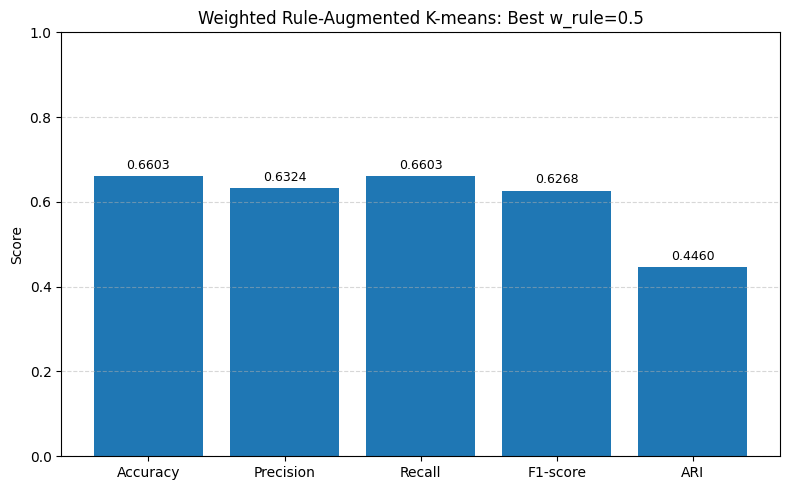

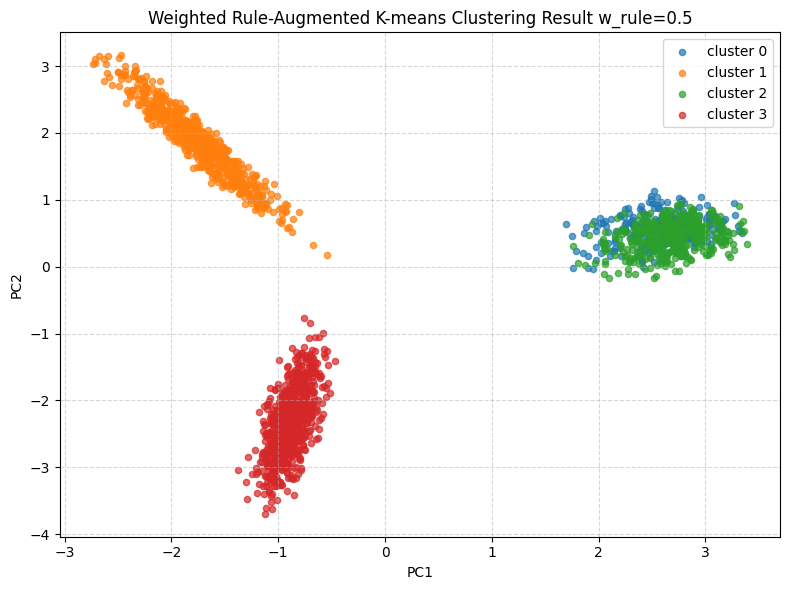

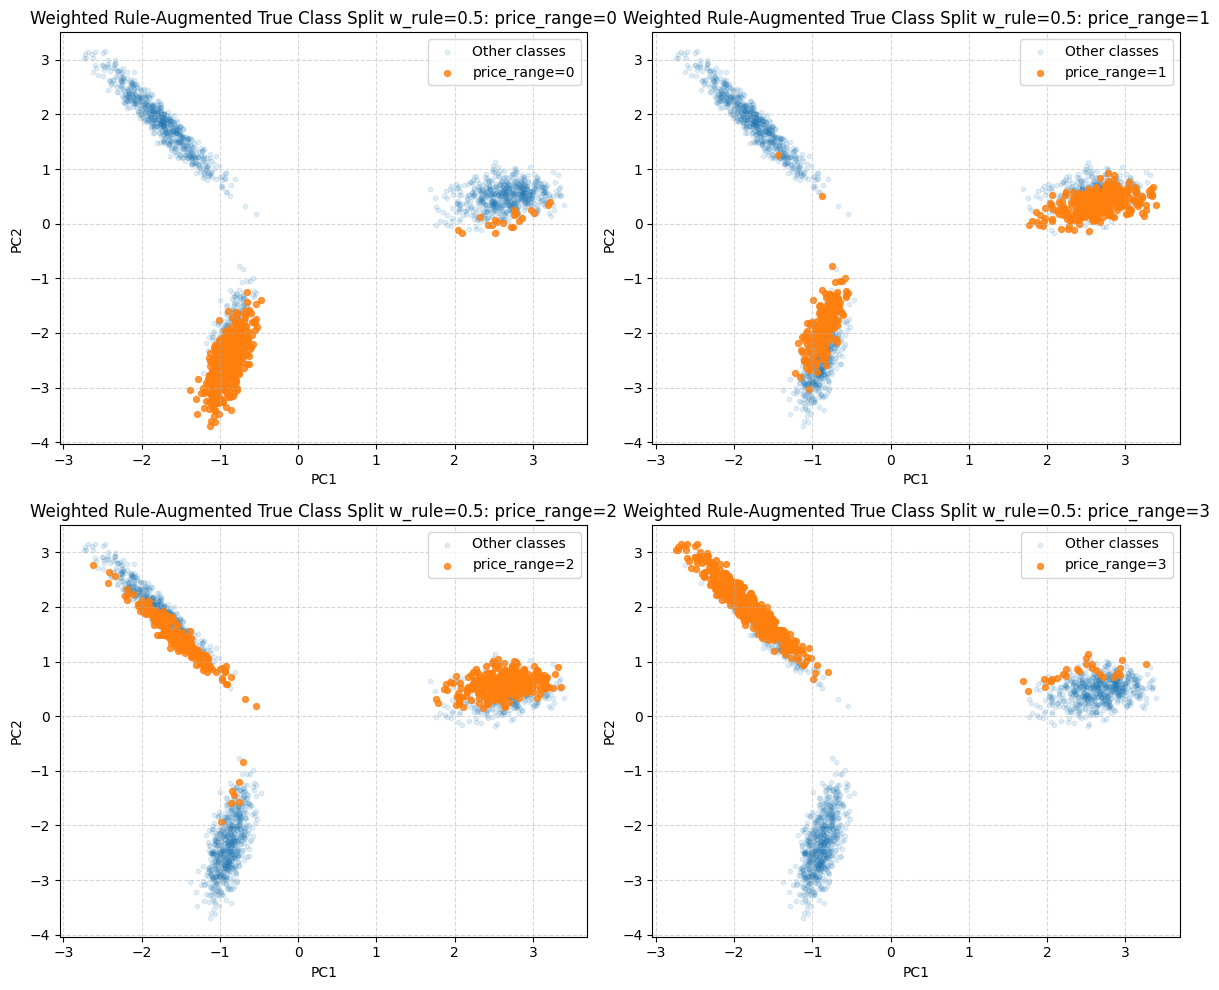

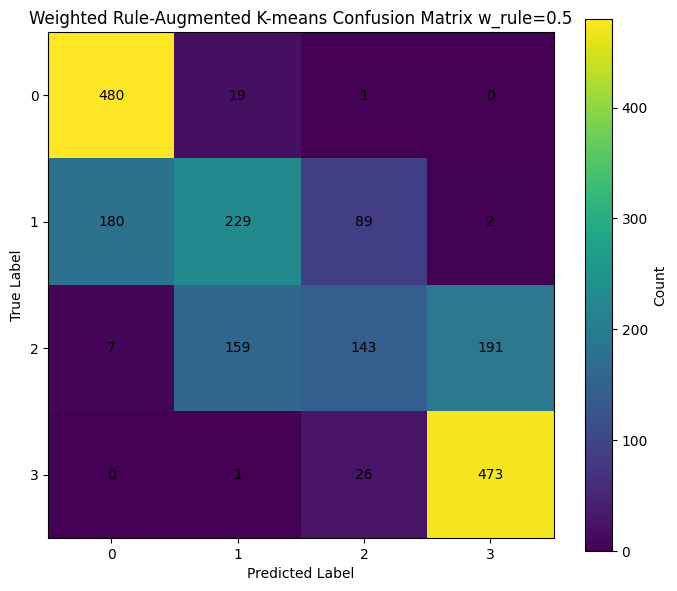

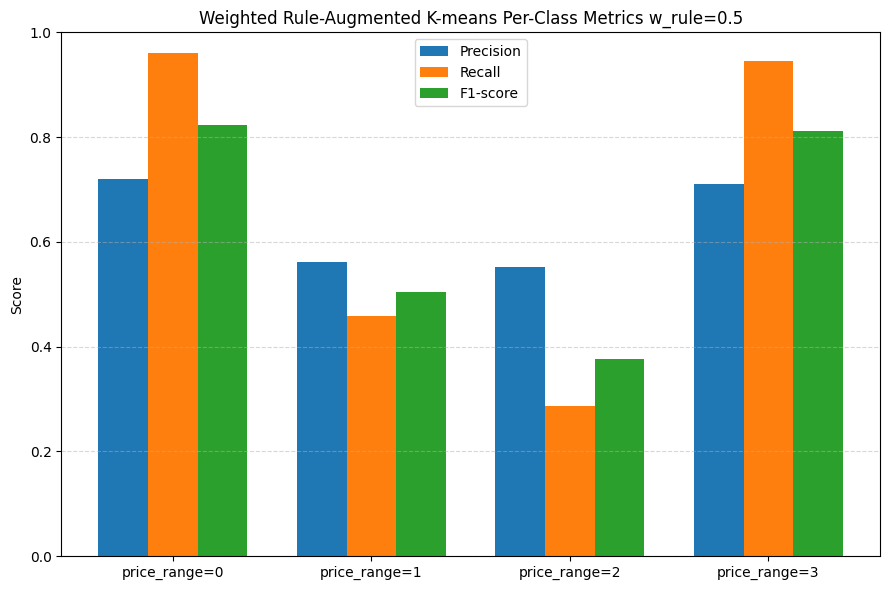

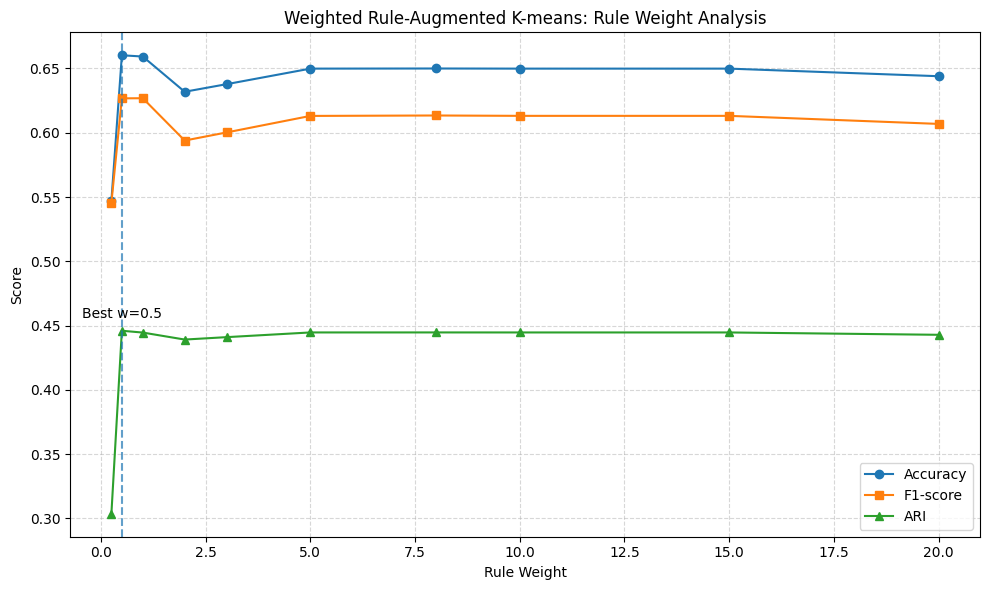

In [8]:
# =========================================================
# 3. Weighted Rule-Augmented K-means
# =========================================================

weight_list = [0.25, 0.5, 1, 2, 3, 5, 8, 10, 15, 20]

scaler_original = StandardScaler()
scaler_rule = StandardScaler()

X_original_scaled_for_weight = scaler_original.fit_transform(X_df)
X_rule_scaled_for_weight = scaler_rule.fit_transform(rule_feature_df)

weighted_all_results = []
weighted_feature_dict = {}
weighted_cluster_dict = {}
weighted_pred_dict = {}

for w_rule in weight_list:
    X_weighted = np.concatenate(
        [
            X_original_scaled_for_weight,
            X_rule_scaled_for_weight * w_rule
        ],
        axis=1
    )

    weighted_feature_dict[w_rule] = X_weighted

    for seed in seeds:
        kmeans = KMeans(
            n_clusters=4,
            random_state=seed,
            n_init=30
        )

        clusters = kmeans.fit_predict(X_weighted)

        acc, precision, recall, f1, ari, y_pred = evaluate_clustering(
            y,
            clusters
        )

        weighted_all_results.append({
            "Method": "Weighted Rule-Augmented K-means",
            "Rule Weight": w_rule,
            "seed": seed,
            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1,
            "ARI": ari
        })

        weighted_cluster_dict[(w_rule, seed)] = clusters
        weighted_pred_dict[(w_rule, seed)] = y_pred

weighted_rule_results = pd.DataFrame(weighted_all_results)

# =========================================================
# Average performance for each weight
# =========================================================
weighted_summary = weighted_rule_results.groupby("Rule Weight")[
    ["Accuracy", "Precision", "Recall", "F1-score", "ARI"]
].mean().reset_index()

best_weight_by_ari = weighted_summary.sort_values(
    by="ARI",
    ascending=False
).iloc[0]

best_w_rule = float(best_weight_by_ari["Rule Weight"])

print("\n========== Weighted Rule-Augmented K-means Results: All Weights and Seeds ==========")
display(weighted_rule_results.round(4))

print("\nWeighted Rule-Augmented K-means Average by Weight")
display(weighted_summary.round(4))

print("\n========== Best Weight by ARI ==========")
print(best_weight_by_ari)


# =========================================================
# Best weight: show 5-seed results first
# =========================================================
best_weighted_rows = weighted_rule_results[
    weighted_rule_results["Rule Weight"] == best_w_rule
].copy()

best_weighted_rows["Method"] = (
    f"Weighted Rule-Augmented K-means w_rule={best_w_rule}"
)

print(f"\n Best Weight = {best_w_rule} Results Across 5 Seeds")
display(
    best_weighted_rows[
        ["Method", "seed", "Accuracy", "Precision", "Recall", "F1-score", "ARI"]
    ].round(4)
)


# =========================================================
# Best weighted summary
# =========================================================
best_weighted_summary = summarize_results(
    best_weighted_rows.drop(columns=["Rule Weight"])
)

print(f"\n========== Best Weight = {best_w_rule} Average Performance ==========")
display(best_weighted_summary.round(4))


# =========================================================
# Use seed=42 for visualization
# =========================================================
vis_seed = 42

X_best_weighted = weighted_feature_dict[best_w_rule]
best_weighted_cluster_42 = weighted_cluster_dict[(best_w_rule, vis_seed)]
best_weighted_pred_42 = weighted_pred_dict[(best_w_rule, vis_seed)]


plot_metric_bar(
    best_weighted_summary,
    title=f"Weighted Rule-Augmented K-means: Best w_rule={best_w_rule}",
    save_path=os.path.join(SAVE_FIG_DIR, "03_weighted_metrics.png")
)

plot_cluster_scatter(
    X_best_weighted,
    best_weighted_cluster_42,
    title=f"Weighted Rule-Augmented K-means Clustering Result w_rule={best_w_rule}",
    save_path=os.path.join(SAVE_FIG_DIR, "03_weighted_cluster_scatter.png")
)

plot_true_class_split(
    X_best_weighted,
    y,
    title_prefix=f"Weighted Rule-Augmented True Class Split w_rule={best_w_rule}",
    save_path=os.path.join(SAVE_FIG_DIR, "03_weighted_true_class_split.png")
)

plot_confusion_matrix(
    y,
    best_weighted_pred_42,
    title=f"Weighted Rule-Augmented K-means Confusion Matrix w_rule={best_w_rule}",
    save_path=os.path.join(SAVE_FIG_DIR, "03_weighted_confusion_matrix.png")
)

plot_per_class_metrics(
    y,
    best_weighted_pred_42,
    title=f"Weighted Rule-Augmented K-means Per-Class Metrics w_rule={best_w_rule}",
    save_path=os.path.join(SAVE_FIG_DIR, "03_weighted_per_class_metrics.png")
)


# =========================================================
# Rule weight analysis plot
# =========================================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    weighted_summary["Rule Weight"],
    weighted_summary["Accuracy"],
    marker="o",
    label="Accuracy"
)

ax.plot(
    weighted_summary["Rule Weight"],
    weighted_summary["F1-score"],
    marker="s",
    label="F1-score"
)

ax.plot(
    weighted_summary["Rule Weight"],
    weighted_summary["ARI"],
    marker="^",
    label="ARI"
)

ax.axvline(best_w_rule, linestyle="--", alpha=0.7)

ax.text(
    best_w_rule,
    best_weight_by_ari["ARI"] + 0.01,
    f"Best w={best_w_rule}",
    ha="center",
    fontsize=10
)

ax.set_xlabel("Rule Weight")
ax.set_ylabel("Score")
ax.set_title("Weighted Rule-Augmented K-means: Rule Weight Analysis")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(
    os.path.join(SAVE_FIG_DIR, "03_rule_weight_analysis.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Final Comparison


========== Final Comparison Average Performance ==========


,Method,Accuracy,Precision,Recall,F1-score,ARI
0,Original K-means,0.2952,0.2948,0.2952,0.2933,0.0055
1,Rule-Augmented K-means,0.6593,0.6308,0.6593,0.6269,0.4445
2,Weighted Rule-Augmented K-means w_rule=0.5,0.6603,0.6324,0.6603,0.6268,0.4460


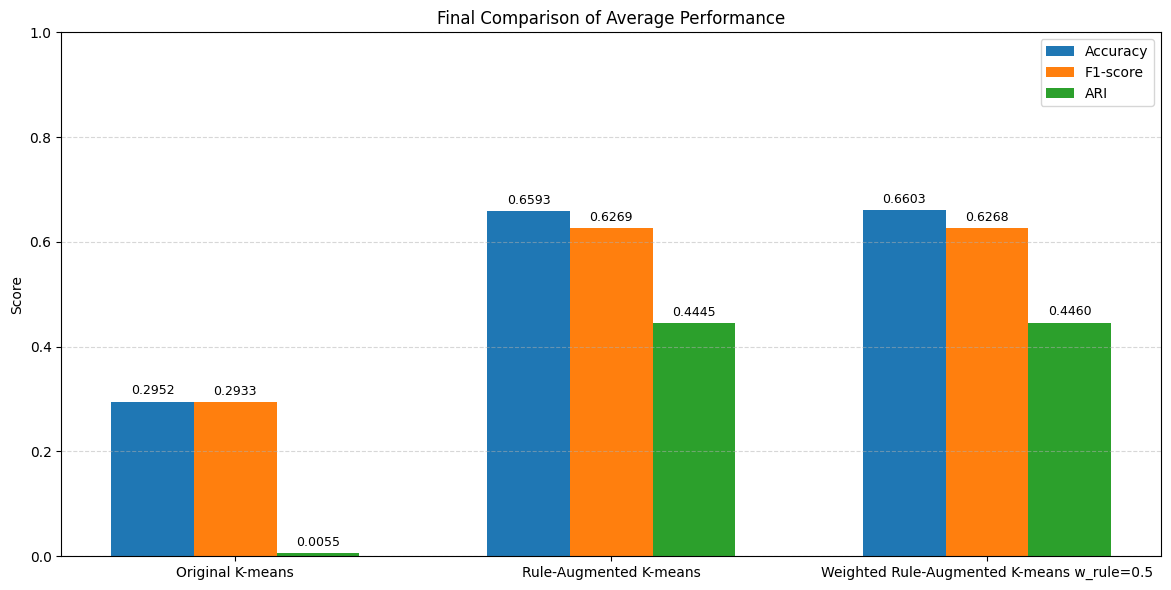


========== Final Best Method ==========

Best by ARI:
Method       Weighted Rule-Augmented K-means w_rule=0.5
Accuracy                                         0.6603
Precision                                      0.632447
Recall                                           0.6603
F1-score                                       0.626769
ARI                                            0.445958
Name: 2, dtype: object

Best by F1-score:
Method       Rule-Augmented K-means
Accuracy                     0.6593
Precision                  0.630846
Recall                       0.6593
F1-score                   0.626876
ARI                        0.444548
Name: 1, dtype: object

Best by Accuracy:
Method       Weighted Rule-Augmented K-means w_rule=0.5
Accuracy                                         0.6603
Precision                                      0.632447
Recall                                           0.6603
F1-score                                       0.626769
ARI                          

In [ ]:
# =========================================================
# Final Comparison
# =========================================================
final_summary = pd.concat(
    [
        original_summary,
        rule_augmented_summary,
        best_weighted_summary
    ],
    axis=0
).reset_index(drop=True)

print("\n========== Final Comparison Average Performance ==========")
display(final_summary.round(4))

plot_final_comparison(
    final_summary,
    save_path=os.path.join(SAVE_FIG_DIR, "04_final_comparison.png")
)


# =========================================================
# Final Best Method
# =========================================================
best_by_ari = final_summary.sort_values(
    by="ARI",
    ascending=False
).iloc[0]

best_by_f1 = final_summary.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]

best_by_acc = final_summary.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print("\n========== Final Best Method ==========")

print("\nBest by ARI:")
print(best_by_ari)

print("\nBest by F1-score:")
print(best_by_f1)

print("\nBest by Accuracy:")
print(best_by_acc)

print("\nAll figures saved to:", SAVE_FIG_DIR)

# Weighted Rule-Augmented K-means Framework

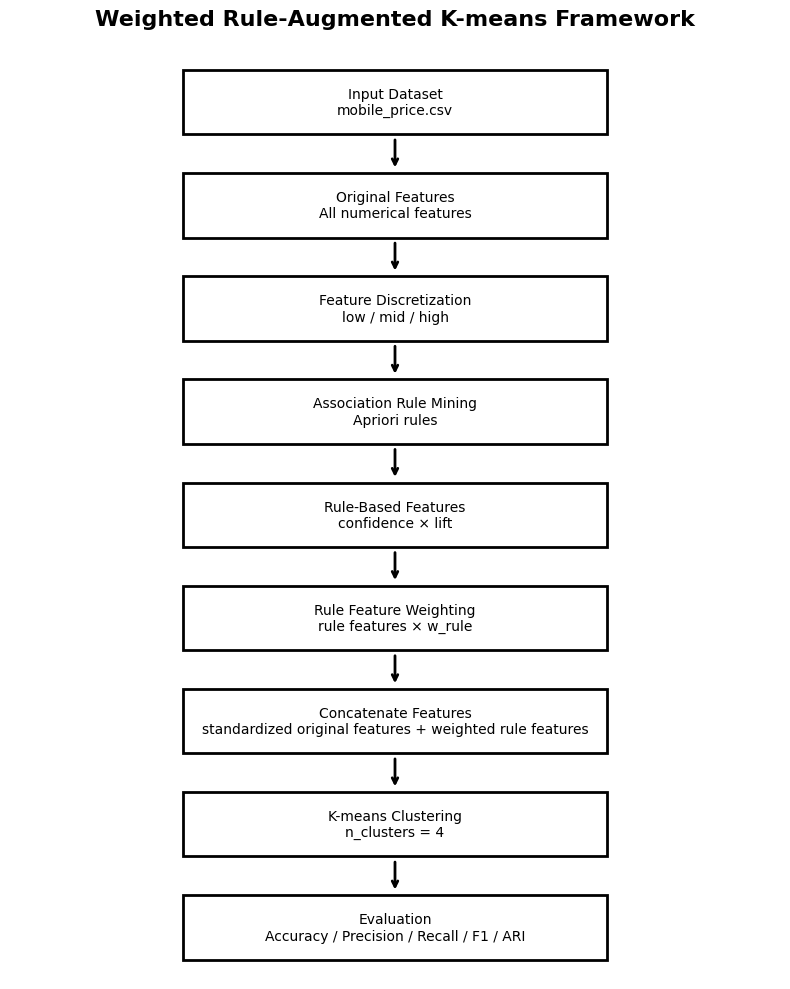

In [ ]:
# =========================================================
# Weighted Rule-Augmented K-means Flowchart - Vertical Version
# =========================================================
import matplotlib.pyplot as plt
import os

SAVE_FIG_DIR = "kmeans_rule_figures"
os.makedirs(SAVE_FIG_DIR, exist_ok=True)

def plot_weighted_rule_augmented_flow_vertical(save_path=None):
    fig, ax = plt.subplots(figsize=(8, 10))
    ax.axis("off")

    boxes = [
        ("Input Dataset\nmobile_price.csv", 0.50, 0.92),
        ("Original Features\nAll numerical features", 0.50, 0.80),
        ("Feature Discretization\nlow / mid / high", 0.50, 0.68),
        ("Association Rule Mining\nApriori rules", 0.50, 0.56),
        ("Rule-Based Features\nconfidence × lift", 0.50, 0.44),
        ("Rule Feature Weighting\nrule features × w_rule", 0.50, 0.32),
        ("Concatenate Features\nstandardized original features + weighted rule features", 0.50, 0.20),
        ("K-means Clustering\nn_clusters = 4", 0.50, 0.08),
        ("Evaluation\nAccuracy / Precision / Recall / F1 / ARI", 0.50, -0.04),
    ]

    box_w = 0.55
    box_h = 0.075

    box_pos = {}

    for text, cx, cy in boxes:
        x = cx - box_w / 2
        y = cy - box_h / 2

        box_pos[text] = (x, y, box_w, box_h)

        rect = plt.Rectangle(
            (x, y),
            box_w,
            box_h,
            fill=False,
            linewidth=2
        )
        ax.add_patch(rect)

        ax.text(
            cx,
            cy,
            text,
            ha="center",
            va="center",
            fontsize=10
        )

    def bottom(text):
        x, y, w, h = box_pos[text]
        return x + w / 2, y

    def top(text):
        x, y, w, h = box_pos[text]
        return x + w / 2, y + h

    for i in range(len(boxes) - 1):
        start_text = boxes[i][0]
        end_text = boxes[i + 1][0]

        ax.annotate(
            "",
            xy=top(end_text),
            xytext=bottom(start_text),
            arrowprops=dict(
                arrowstyle="->",
                lw=2,
                shrinkA=4,
                shrinkB=4
            )
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(-0.10, 1.00)

    ax.set_title(
        "Weighted Rule-Augmented K-means Framework",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_weighted_rule_augmented_flow_vertical(
    save_path=os.path.join(
        SAVE_FIG_DIR,
        "weighted_rule_augmented_kmeans_flow_vertical.png"
    )
)